In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import shap

In [2]:
path = "../data_part3"

df = pd.read_csv(f"{path}/all_data_with_identities-2.csv", sep=",")


<h2>Analyse des données</h2>

In [3]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.head(5)

,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,wow,...,asian_latino_etc,disability_any,identity_any,num_identities,more_than_one_identity,na_gender,na_orientation,na_religion,na_race,na_disability
0,627762,OH yes - Were those evil Christian Missionarie...,test,2016-11-26 15:56:03.862109+00,13,627198.0,152737,approved,0,0,...,0,0,1,1.0,False,1,1,0,1,1
1,5892815,Why is this black racist crap still on the G&M...,val,2017-09-03 23:20:08.226613+00,54,NaN,373428,rejected,0,0,...,0,0,1,2.0,True,1,1,1,0,1
2,416437,even up here.......BLACKS!,train,2016-08-04 16:48:07.175252+00,21,NaN,143025,rejected,0,0,...,0,0,1,1.0,False,1,1,1,0,1
3,5137126,Blame men. There's always an excuse to blame ...,train,2017-04-15 19:00:45.032674+00,54,5136907.0,327125,rejected,0,0,...,0,0,1,2.0,True,0,1,1,1,1
4,855753,And the woman exposing herself saying grab thi...,val,2017-01-18 01:50:57.478867+00,13,849081.0,162008,rejected,0,0,...,0,0,1,1.0,False,0,1,1,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448000 entries, 0 to 447999
Data columns (total 58 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   id                                   448000 non-null  int64  
 1   comment_text                         447998 non-null  object 
 2   split                                448000 non-null  object 
 3   created_date                         448000 non-null  object 
 4   publication_id                       448000 non-null  int64  
 5   parent_id                            259716 non-null  float64
 6   article_id                           448000 non-null  int64  
 7   rating                               448000 non-null  object 
 8   funny                                448000 non-null  int64  
 9   wow                                  448000 non-null  int64  
 10  sad                                  448000 non-null  int64  
 11  likes        

In [6]:
df['longueur_texte'] = df['comment_text'].apply(lambda x: len(str(x)))

In [7]:
df.head()

,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,wow,...,disability_any,identity_any,num_identities,more_than_one_identity,na_gender,na_orientation,na_religion,na_race,na_disability,longueur_texte
0,627762,OH yes - Were those evil Christian Missionarie...,test,2016-11-26 15:56:03.862109+00,13,627198.0,152737,approved,0,0,...,0,1,1.0,False,1,1,0,1,1,253
1,5892815,Why is this black racist crap still on the G&M...,val,2017-09-03 23:20:08.226613+00,54,NaN,373428,rejected,0,0,...,0,1,2.0,True,1,1,1,0,1,688
2,416437,even up here.......BLACKS!,train,2016-08-04 16:48:07.175252+00,21,NaN,143025,rejected,0,0,...,0,1,1.0,False,1,1,1,0,1,26
3,5137126,Blame men. There's always an excuse to blame ...,train,2017-04-15 19:00:45.032674+00,54,5136907.0,327125,rejected,0,0,...,0,1,2.0,True,0,1,1,1,1,76
4,855753,And the woman exposing herself saying grab thi...,val,2017-01-18 01:50:57.478867+00,13,849081.0,162008,rejected,0,0,...,0,1,1.0,False,0,1,1,1,1,165


In [8]:
df.describe()

,id,publication_id,parent_id,article_id,funny,wow,sad,likes,disagree,toxicity,...,asian_latino_etc,disability_any,identity_any,num_identities,na_gender,na_orientation,na_religion,na_race,na_disability,longueur_texte
count,4.480000e+05,448000.000000,2.597160e+05,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,...,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000,448000.000000
mean,4.056301e+06,50.185348,3.690551e+06,281036.162795,0.268330,0.046234,0.112442,2.555719,0.596433,0.140029,...,0.016560,0.012408,0.418891,0.582422,0.801808,0.971623,0.843417,0.904228,0.987592,351.742958
std,2.528068e+06,26.642190,2.455927e+06,103687.331980,1.062244,0.255272,0.464451,4.907267,1.874960,0.218396,...,0.127617,0.110700,0.493378,0.821336,0.398638,0.166048,0.363407,0.294279,0.110700,289.323717
min,5.985600e+04,2.000000,6.618700e+04,2006.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,8.625082e+05,21.000000,7.893630e+05,160211.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,121.000000
50%,5.338636e+06,54.000000,5.202036e+06,331566.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,257.000000
75%,5.963358e+06,54.000000,5.780144e+06,366752.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.200000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,512.000000
max,7.194631e+06,111.000000,6.333789e+06,399541.000000,95.000000,15.000000,24.000000,186.000000,173.000000,1.000000,...,1.000000,1.000000,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1891.000000


In [9]:
df_toxique = df[df['toxicity'] >= 0.5]

df_toxique.describe()

,id,publication_id,parent_id,article_id,funny,wow,sad,likes,disagree,toxicity,...,asian_latino_etc,disability_any,identity_any,num_identities,na_gender,na_orientation,na_religion,na_race,na_disability,longueur_texte
count,5.079400e+04,50794.000000,2.771300e+04,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,...,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000,50794.000000
mean,4.094972e+06,51.564693,3.725392e+06,284045.526381,0.236544,0.053609,0.127023,2.527720,0.647163,0.642111,...,0.021085,0.022601,0.606843,0.908434,0.741977,0.930582,0.813639,0.775859,0.977399,324.020947
std,2.530464e+06,29.577845,2.471908e+06,103877.805611,0.993323,0.273773,0.503301,5.169045,1.961195,0.133405,...,0.143670,0.148629,0.488456,0.961028,0.437551,0.254166,0.389401,0.417019,0.148629,264.927574
min,5.985600e+04,2.000000,2.395810e+05,2006.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,8.723398e+05,21.000000,7.915980e+05,160597.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,122.000000
50%,5.393973e+06,54.000000,5.248303e+06,335105.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.600000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,238.000000
75%,6.002489e+06,55.000000,5.824297e+06,369619.500000,0.000000,0.000000,0.000000,3.000000,0.000000,0.718310,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,448.000000
max,7.194551e+06,111.000000,6.333272e+06,399530.000000,95.000000,6.000000,14.000000,166.000000,83.000000,1.000000,...,1.000000,1.000000,1.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1000.000000


In [10]:
df_non_toxique = df[df['toxicity'] < 0.5]

df_non_toxique.describe()

,id,publication_id,parent_id,article_id,funny,wow,sad,likes,disagree,toxicity,...,asian_latino_etc,disability_any,identity_any,num_identities,na_gender,na_orientation,na_religion,na_race,na_disability,longueur_texte
count,3.972060e+05,397206.000000,2.320030e+05,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,...,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000,397206.000000
mean,4.051355e+06,50.008960,3.686390e+06,280651.330707,0.272395,0.045291,0.110577,2.559299,0.589946,0.075824,...,0.015982,0.011105,0.394856,0.540732,0.809459,0.976871,0.847225,0.920643,0.988895,355.287999
std,2.527722e+06,26.237924,2.453984e+06,103656.779878,1.070671,0.252794,0.459213,4.872772,1.863548,0.123133,...,0.125404,0.104794,0.488820,0.792102,0.392728,0.150314,0.359771,0.270295,0.104794,292.107289
min,2.395790e+05,6.000000,6.618700e+04,2476.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,8.611695e+05,21.000000,7.890835e+05,160158.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,121.000000
50%,5.332350e+06,54.000000,5.197359e+06,331108.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,260.000000
75%,5.957870e+06,54.000000,5.773250e+06,366329.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.166667,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,521.000000
max,7.194631e+06,111.000000,6.333789e+06,399541.000000,94.000000,15.000000,24.000000,186.000000,173.000000,0.493827,...,1.000000,1.000000,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1891.000000


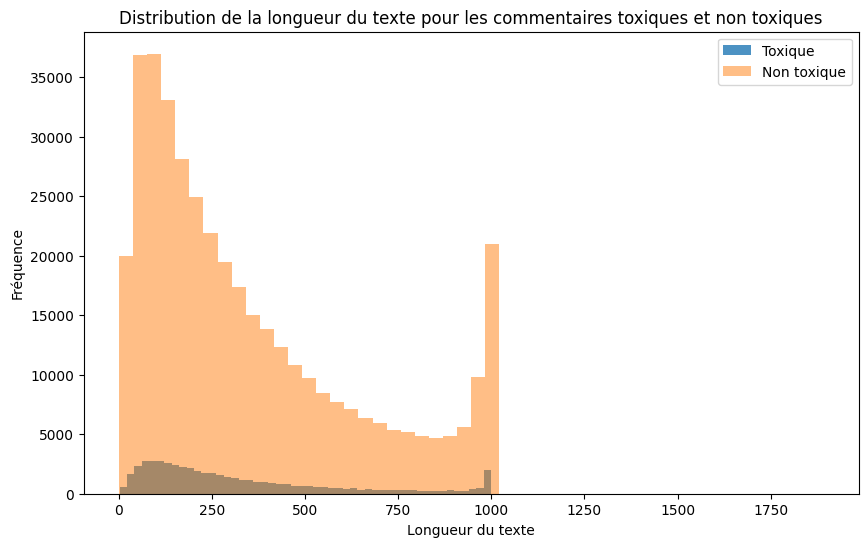

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df_toxique['longueur_texte'], bins=50, alpha=0.8, label='Toxique')
plt.hist(df_non_toxique['longueur_texte'], bins=50, alpha=0.5, label='Non toxique')
plt.xlabel('Longueur du texte')
plt.ylabel('Fréquence')
plt.title('Distribution de la longueur du texte pour les commentaires toxiques et non toxiques')
plt.legend()
plt.show()

/var/folders/qc/5qn44xzs143g6s6sy04v51qm0000gn/T/ipykernel_36413/2430239103.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


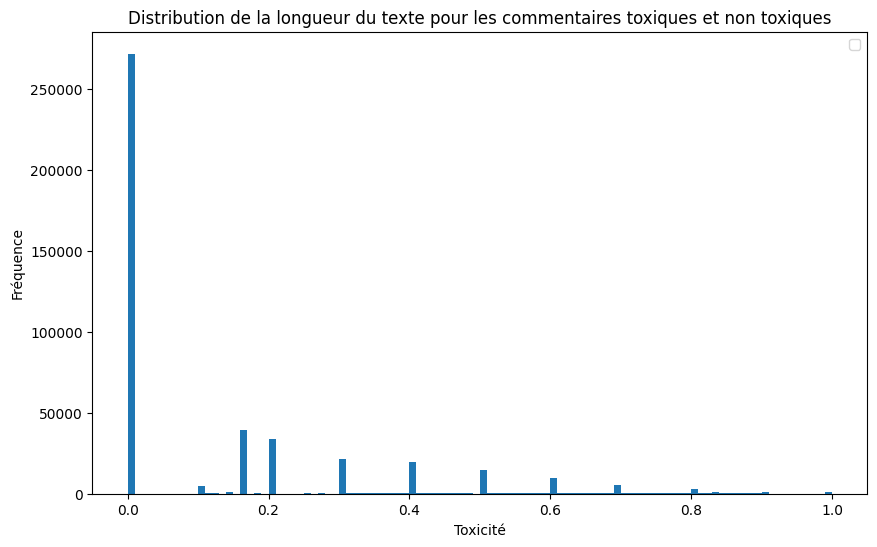

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['toxicity'], bins=100)
plt.xlabel('Toxicité')
plt.ylabel('Fréquence')
plt.title('Distribution de la longueur du texte pour les commentaires toxiques et non toxiques')
plt.legend()
plt.show()

La distribution des longueurs est asymétrique mais similaire dans les deux classes: la plus grande majorité des commentaires sont relativement courts. Sur l’histogramme ci-dessus, on observe que la distribution est plutot similaire que ce soit pour les commentaires toxiques, ou non toxiques. Ainsi la longueur seule n'est pas un critère suffisant pour faire la distinction entre un commentaire toxique et un non-toxique. 

Le dataset est fortement déséquilibré en faveur de la classe non toxique. Nous allons éventuellement pouvoir utiliser des algo de rééquilibrage des classes, comme SMOTE. Il faut aussi privilégier des métriques adaptées, comme F1-score, le recall, AUC... 

La colonne toxicity est fortement concentrée vers les valeurs très proches de 0. Cela confirme que les cas toxiques sont largement minoritaires. La binarisation avec un seuil de 0.5 nous parait pertinente, mais si des données supplémentaires sont nécessaires, on pourrait simplement décaler ce seuil vers des valeurs plus faibles, puisqu'il y a une certaine ambiguïté dans ces cas.



<h2>Prétraitement et visualisation</h2>

In [20]:
def nettoyer_texte(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"([!?.,;:])\1+", r"\1", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment_text_clean"] = df["comment_text"].apply(nettoyer_texte)

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)

df["tokens"] = df["comment_text_clean"].apply(
    lambda x: [
        tok
        for tok in tokenizer.tokenize(x)
        if tok.strip() and len(tok) > 1 and not tok.isnumeric()
    ]
)

df["nb_tokens"] = df["tokens"].apply(len)

print("Statistiques globales du nombre de tokens (sans suppression des stopwords):")
display(df["nb_tokens"].describe())

Statistiques globales du nombre de tokens (sans suppression des stopwords):


count    448000.000000
mean         58.289964
std          47.755884
min           0.000000
25%          20.000000
50%          43.000000
75%          85.000000
max         304.000000
Name: nb_tokens, dtype: float64

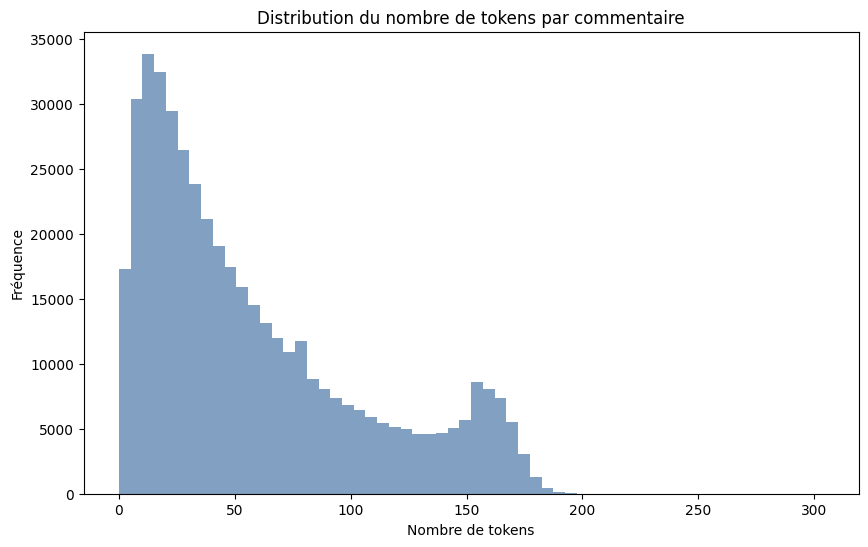

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(df["nb_tokens"], bins=60, alpha=0.7, color="#4C78A8")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de tokens par commentaire")
plt.show()

In [22]:
lemmatizer = WordNetLemmatizer()

df["lemmes"] = df["tokens"].apply(lambda toks: [lemmatizer.lemmatize(tok) for tok in toks])

display(df[["tokens", "lemmes"]].head(5))

,tokens,lemmes
0,"[oh, yes, were, those, evil, christian, missio...","[oh, yes, were, those, evil, christian, missio..."
1,"[why, is, this, black, racist, crap, still, on...","[why, is, this, black, racist, crap, still, on..."
2,"[even, up, here, blacks]","[even, up, here, black]"
3,"[blame, men, there, always, an, excuse, to, bl...","[blame, men, there, always, an, excuse, to, bl..."
4,"[and, the, woman, exposing, herself, saying, g...","[and, the, woman, exposing, herself, saying, g..."


In [23]:
df_non_toxique = df[df['toxicity'] < 0.5]

distrib_mots_non_toxiques = {}
for lems in df_non_toxique['lemmes']:
    for lem in lems :
        if lem in distrib_mots_non_toxiques:
            distrib_mots_non_toxiques[lem] += 1
        else:
            distrib_mots_non_toxiques[lem] = 1

df_toxique = df[df['toxicity'] >= 0.5]
distrib_mots_toxiques = {}
for lems in df_toxique['lemmes']:
    for lem in lems :
        if lem in distrib_mots_toxiques:
            distrib_mots_toxiques[lem] += 1
        else:
            distrib_mots_toxiques[lem] = 1

In [25]:
#retrait des stop-words
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

stop_words_en = set(stopwords.words("english"))
stop_words_custom = {
    "im", "ive", "youre", "theyre", "weve", "thats", "dont", "didnt",
    "cant", "couldnt", "wouldnt", "etc"
}
stop_words = stop_words_en | stop_words_custom

for lem in list(distrib_mots_non_toxiques.keys()):
    if lem in stop_words:
        del distrib_mots_non_toxiques[lem]

for lem in list(distrib_mots_toxiques.keys()):
    if lem in stop_words:
        del distrib_mots_toxiques[lem]



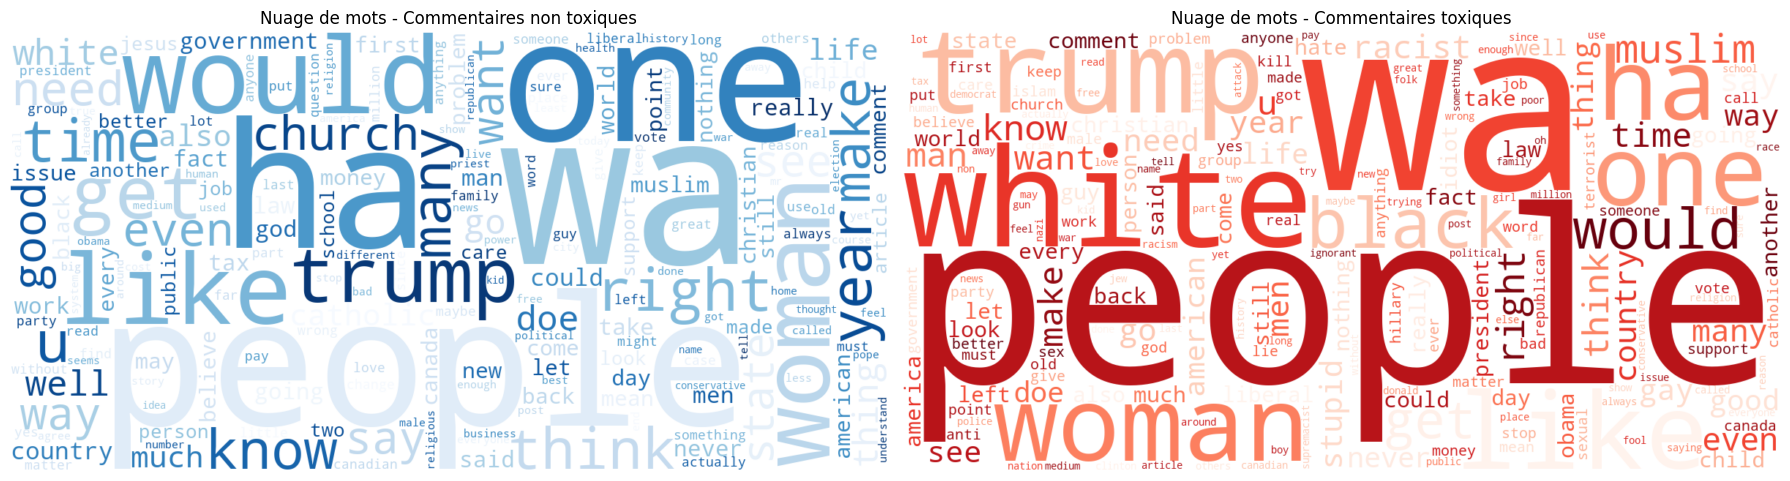

In [26]:
wordcloud_non_toxique = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues"
).generate_from_frequencies(distrib_mots_non_toxiques)

wordcloud_toxique = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"
).generate_from_frequencies(distrib_mots_toxiques)

plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_non_toxique, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots - Commentaires non toxiques")

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_toxique, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots - Commentaires toxiques")

plt.tight_layout()
plt.show()

In [ ]:
termes_communs = set(distrib_mots_non_toxiques).intersection(distrib_mots_toxiques)
print(f"Nombre de termes communs: {len(termes_communs)}")

df_ambigus = pd.DataFrame({
    "terme": list(termes_communs),
    "freq_non_toxique": [distrib_mots_non_toxiques[t] for t in termes_communs],
    "freq_toxique": [distrib_mots_toxiques[t] for t in termes_communs],
})
df_ambigus["freq_totale"] = df_ambigus["freq_non_toxique"] + df_ambigus["freq_toxique"]
df_ambigus["part_toxique"] = df_ambigus["freq_toxique"] / df_ambigus["freq_totale"]

df_ambigus["ambiguite"] = (1 - (df_ambigus["part_toxique"] - 0.5).abs() * 2) * df_ambigus["freq_totale"]

seuil_freq = 20
df_ambigus_filtres = df_ambigus[df_ambigus["freq_totale"] >= seuil_freq].copy()

print("\nTop 20 des termes les plus ambigus (frequents et partages):")
display(
    df_ambigus_filtres.sort_values("ambiguite", ascending=False)
    .head(20)
    [["terme", "freq_non_toxique", "freq_toxique", "freq_totale", "part_toxique", "ambiguite"]]
    .reset_index(drop=True)
    .style.format({"part_toxique": "{:.2f}", "ambiguite": "{:.2f}"})
)

print("\nTop 20 termes communs les plus frequents (brut):")
display(
    df_ambigus.sort_values("freq_totale", ascending=False)
    .head(20)
    [["terme", "freq_non_toxique", "freq_toxique", "freq_totale", "part_toxique"]]
    .reset_index(drop=True)
    .style.format({"part_toxique": "{:.2f}"})
)

Nombre de termes communs: 38278

Top 20 des termes les plus ambigus (frequents et partages):


,terme,freq_non_toxique,freq_toxique,freq_totale,part_toxique,ambiguite
0,wa,125273,13166,138439,0.10,26332.00
1,people,84883,13113,97996,0.13,26226.00
2,white,31989,12547,44536,0.28,25094.00
3,trump,53707,12372,66079,0.19,24744.00
4,like,64963,10048,75011,0.13,20096.00
5,woman,64018,9748,73766,0.13,19496.00
6,ha,78829,8895,87724,0.10,17790.00
7,one,77743,8353,86096,0.10,16706.00
8,black,17605,8065,25670,0.31,16130.00
9,would,77336,8054,85390,0.09,16108.00



Top 20 termes communs les plus frequents (brut):


,terme,freq_non_toxique,freq_toxique,freq_totale,part_toxique
0,wa,125273,13166,138439,0.10
1,people,84883,13113,97996,0.13
2,ha,78829,8895,87724,0.10
3,one,77743,8353,86096,0.10
4,would,77336,8054,85390,0.09
5,like,64963,10048,75011,0.13
6,woman,64018,9748,73766,0.13
7,trump,53707,12372,66079,0.19
8,get,49649,6813,56462,0.12
9,right,47798,6112,53910,0.11


In [ ]:

documents = df["lemmes"].apply(lambda toks: " ".join(toks) if isinstance(toks, list) else "")

labels = (df["toxicity"] >= 0.5).astype(int).to_numpy()

vectorizer = TfidfVectorizer(min_df=20, max_df=0.95)
X = vectorizer.fit_transform(documents)
terms = vectorizer.get_feature_names_out()

mean_tox = X[labels == 1].mean(axis=0).A1
mean_non_tox = X[labels == 0].mean(axis=0).A1

df_tfidf_classes = pd.DataFrame({
    "terme": terms,
    "tfidf_moy_toxique": mean_tox,
    "tfidf_moy_non_toxique": mean_non_tox,
})

eps = 1e-9
df_tfidf_classes["ratio_tox_vs_non"] = (df_tfidf_classes["tfidf_moy_toxique"] + eps) / (df_tfidf_classes["tfidf_moy_non_toxique"] + eps)
df_tfidf_classes["ratio_non_vs_tox"] = (df_tfidf_classes["tfidf_moy_non_toxique"] + eps) / (df_tfidf_classes["tfidf_moy_toxique"] + eps)

tox_uniques_stricts = df_tfidf_classes[
    (df_tfidf_classes["tfidf_moy_toxique"] > 0) & (df_tfidf_classes["tfidf_moy_non_toxique"] == 0)
].sort_values("tfidf_moy_toxique", ascending=False)

non_tox_uniques_stricts = df_tfidf_classes[
    (df_tfidf_classes["tfidf_moy_non_toxique"] > 0) & (df_tfidf_classes["tfidf_moy_toxique"] == 0)
].sort_values("tfidf_moy_non_toxique", ascending=False)

q_tox = df_tfidf_classes["tfidf_moy_toxique"].quantile(0.95)
q_non = df_tfidf_classes["tfidf_moy_non_toxique"].quantile(0.95)

tox_uniques_quasi = df_tfidf_classes[
    (df_tfidf_classes["tfidf_moy_toxique"] >= q_tox)
    & (df_tfidf_classes["ratio_tox_vs_non"] >= 8)
].sort_values(["ratio_tox_vs_non", "tfidf_moy_toxique"], ascending=False)

non_tox_uniques_quasi = df_tfidf_classes[
    (df_tfidf_classes["tfidf_moy_non_toxique"] >= q_non)
    & (df_tfidf_classes["ratio_non_vs_tox"] >= 8)
].sort_values(["ratio_non_vs_tox", "tfidf_moy_non_toxique"], ascending=False)

print("Top 20 termes TF-IDF eleve uniquement toxique (strict):")
display(tox_uniques_stricts.head(20).reset_index(drop=True))

print("Top 20 termes TF-IDF eleve uniquement non toxique (strict):")
display(non_tox_uniques_stricts.head(20).reset_index(drop=True))

print("Top 20 termes TF-IDF eleve toxique (quasi-exclusifs, ratio >= 8):")
display(tox_uniques_quasi.head(20).reset_index(drop=True))

print("Top 20 termes TF-IDF eleve non toxique (quasi-exclusifs, ratio >= 8):")
display(non_tox_uniques_quasi.head(20).reset_index(drop=True))

Top 20 termes TF-IDF eleve uniquement toxique (strict):


,terme,tfidf_moy_toxique,tfidf_moy_non_toxique,ratio_tox_vs_non,ratio_non_vs_tox


Top 20 termes TF-IDF eleve uniquement non toxique (strict):


,terme,tfidf_moy_toxique,tfidf_moy_non_toxique,ratio_tox_vs_non,ratio_non_vs_tox
0,etf,0.0,0.000082,0.000012,81579.823420
1,diaconate,0.0,0.000065,0.000015,65313.105509
2,missal,0.0,0.000052,0.000019,52024.421426
3,skiing,0.0,0.000049,0.000020,49022.216800
4,hv,0.0,0.000049,0.000021,48735.996423
5,dnr,0.0,0.000046,0.000022,46381.714863
6,biking,0.0,0.000046,0.000022,45511.927833
7,pauline,0.0,0.000044,0.000022,44480.483732
8,sola,0.0,0.000044,0.000023,44367.053922
9,stakeholder,0.0,0.000044,0.000023,44129.598689


Top 20 termes TF-IDF eleve toxique (quasi-exclusifs, ratio >= 8):


,terme,tfidf_moy_toxique,tfidf_moy_non_toxique,ratio_tox_vs_non,ratio_non_vs_tox
0,fuck,0.000853,0.000005,163.719334,0.006108
1,idiot,0.008658,0.000067,129.422110,0.007727
2,imbecile,0.000802,0.000007,109.582609,0.009126
3,moron,0.003154,0.000044,71.479507,0.013990
4,shit,0.001261,0.000018,69.965624,0.014293
5,pussy,0.001204,0.000018,68.097627,0.014685
6,stupid,0.012864,0.000220,58.434497,0.017113
7,bitch,0.001797,0.000034,53.333722,0.018750
8,stupidity,0.003052,0.000057,53.258628,0.018776
9,idiotic,0.001464,0.000028,52.530222,0.019037


Top 20 termes TF-IDF eleve non toxique (quasi-exclusifs, ratio >= 8):


,terme,tfidf_moy_toxique,tfidf_moy_non_toxique,ratio_tox_vs_non,ratio_non_vs_tox


<h2>Analyse des groupes démographiques</h2>

Pour chaque groupe sensible (binarisé avec un seuil de 0.5), on calcule:
- le nombre d'exemples du groupe,
- le taux de toxicité du groupe (avec `toxicity >= 0.5`).

In [34]:
df.columns.to_list()

['id',
 'comment_text',
 'split',
 'created_date',
 'publication_id',
 'parent_id',
 'article_id',
 'rating',
 'funny',
 'wow',
 'sad',
 'likes',
 'disagree',
 'toxicity',
 'severe_toxicity',
 'obscene',
 'sexual_explicit',
 'identity_attack',
 'insult',
 'threat',
 'male',
 'female',
 'transgender',
 'other_gender',
 'heterosexual',
 'homosexual_gay_or_lesbian',
 'bisexual',
 'other_sexual_orientation',
 'christian',
 'jewish',
 'muslim',
 'hindu',
 'buddhist',
 'atheist',
 'other_religion',
 'black',
 'white',
 'asian',
 'latino',
 'other_race_or_ethnicity',
 'physical_disability',
 'intellectual_or_learning_disability',
 'psychiatric_or_mental_illness',
 'other_disability',
 'identity_annotator_count',
 'toxicity_annotator_count',
 'LGBTQ',
 'other_religions',
 'asian_latino_etc',
 'disability_any',
 'identity_any',
 'num_identities',
 'more_than_one_identity',
 'na_gender',
 'na_orientation',
 'na_religion',
 'na_race',
 'na_disability',
 'longueur_texte',
 'comment_text_clean',
 '

In [35]:
sensitive_cols = [
    "male", "female", "transgender", "other_gender",
    "heterosexual", "homosexual_gay_or_lesbian", "bisexual", "other_sexual_orientation",
    "christian", "jewish", "muslim", "hindu", "buddhist", "atheist", "other_religion",
    "black", "white", "asian", "latino", "other_race_or_ethnicity",
    "physical_disability", "intellectual_or_learning_disability",
    "psychiatric_or_mental_illness", "other_disability"
]


df["toxique_binaire"] = (df["toxicity"] >= 0.5).astype(int)

resultats_groupes = []
for col in sensitive_cols:
    groupe_binaire = (df[col] >= 0.5)
    n_exemples = int(groupe_binaire.sum())

    if n_exemples == 0:
        taux_toxicite = float("nan")
        n_toxiques = 0
    else:
        taux_toxicite = float(df.loc[groupe_binaire, "toxique_binaire"].mean())
        n_toxiques = int(df.loc[groupe_binaire, "toxique_binaire"].sum())

    resultats_groupes.append({
        "groupe": col,
        "nb_exemples": n_exemples,
        "nb_toxiques": n_toxiques,
        "taux_toxicite": taux_toxicite,
    })

df_groupes = pd.DataFrame(resultats_groupes).sort_values("taux_toxicite", ascending=False)
df_groupes["taux_toxicite"] = (df_groupes["taux_toxicite"] * 100).round(2)

print("Taux de toxicite et nombre d'exemples par groupe sensible (seuil 0.5):")
display(df_groupes.reset_index(drop=True))

Taux de toxicite et nombre d'exemples par groupe sensible (seuil 0.5):


,groupe,nb_exemples,nb_toxiques,taux_toxicite
0,black,16420,5181,31.55
1,other_gender,10,3,30.00
2,homosexual_gay_or_lesbian,12062,3411,28.28
3,white,27534,7780,28.26
4,other_sexual_orientation,11,3,27.27
5,muslim,23046,5264,22.84
6,heterosexual,1432,323,22.56
7,bisexual,321,69,21.50
8,transgender,2759,583,21.13
9,psychiatric_or_mental_illness,5400,1136,21.04


<h2>Classification</h2>

## Entraînement d'un modèle (80/20) et évaluation

Nous choisissons un **SVM linéaire (`LinearSVC`)** avec représentation **TF-IDF** car ce modèle est adapté aux données textuelles en grande dimension (sparse) et est généralement robuste et performant en classification binaire de texte.

Le label prédit est :
- `toxicity_binary = 1` si `toxicity >= 0.5`
- `toxicity_binary = 0` sinon

Taille train: 358400 | Taille test: 89600
Taux toxicité train: 11.34 %
Taux toxicité test: 11.34 %

=== Métriques (classe positive = toxique) ===
Accuracy      : 0.9176
Precision     : 0.7084
Recall        : 0.4650
F1-score      : 0.5614
ROC-AUC       : 0.8988
PR-AUC        : 0.6489

=== Classification report ===
              precision    recall  f1-score   support

 non toxique       0.93      0.98      0.95     79441
     toxique       0.71      0.47      0.56     10159

    accuracy                           0.92     89600
   macro avg       0.82      0.72      0.76     89600
weighted avg       0.91      0.92      0.91     89600



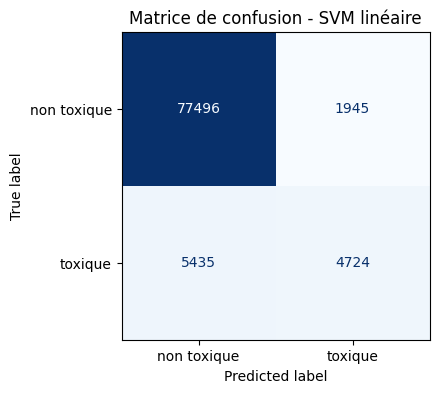

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)

y = (df["toxicity"] >= 0.5).astype(int)
X_text = df["lemmes"].apply(lambda toks: " ".join(toks) if isinstance(toks, list) else "")


X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Taille train:", len(X_train), "| Taille test:", len(X_test))
print("Taux toxicité train:", round(y_train.mean() * 100, 2), "%")
print("Taux toxicité test:", round(y_test.mean() * 100, 2), "%")


model = make_pipeline(
    TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        max_features=60000,
        sublinear_tf=True,
    ),
    LinearSVC(C=1.0),
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_score = model.decision_function(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)

print("\n=== Métriques (classe positive = toxique) ===")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")
print(f"PR-AUC        : {pr_auc:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=["non toxique", "toxique"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non toxique", "toxique"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matrice de confusion - SVM linéaire")
plt.show()

### Commentaire des résultats

Résultats observés sur le test (20%) :
- Accuracy = **0.9176**
- Precision (toxique) = **0.7084**
- Recall (toxique) = **0.4650**
- F1 (toxique) = **0.5614**
- ROC-AUC = **0.8988**
- PR-AUC = **0.6489**

Interprétation :
- Le modèle sépare globalement bien les classes (AUC élevée), mais il manque tout de même une partie des commentaires toxiques 
- La précision sur la classe toxique est correcte : quand le modèle prédit "toxique", il a raison la majorité du temps


### 4. Explicabilité

On applique SHAP sur le classifieur linéaire entraîné sur TF-IDF pour identifier les termes qui influencent le plus les prédictions.

Top termes les plus influents (importance globale SHAP):


,term,mean_abs_shap
0,stupid,0.029218
1,idiot,0.009396
2,crap,0.008379
3,pathetic,0.008259
4,ignorant,0.007631
5,racist,0.004866
6,muslim,0.004568
7,ignorance,0.004402
8,rat,0.004220
9,ole,0.004150


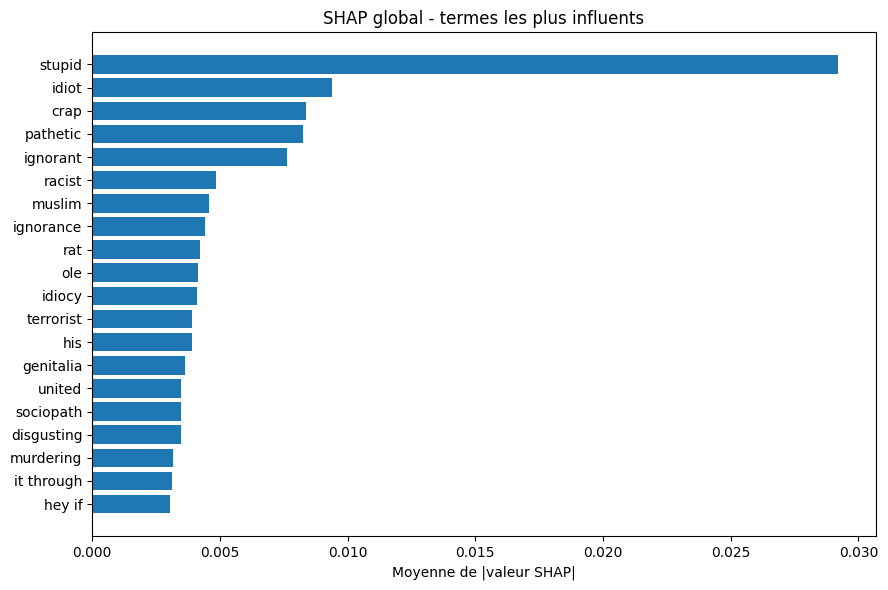


Termes qui poussent vers la classe toxique (coef > 0):


,term,coef
0,stupid,14.842483
1,idiot,14.350045
2,stupidity,9.731041
3,idiotic,8.921026
4,hypocrite,8.324595
5,pathetic,8.312719
6,crap,7.648615
7,shit,7.593339
8,moron,7.579044
9,ignorant,7.343597


Termes qui poussent vers la classe non toxique (coef < 0):


,term,coef
0,collaboration,-3.240491
1,knee jerk,-3.205615
2,to fool,-2.367191
3,beat the,-2.165009
4,witch hunt,-2.083192
5,april,-2.070086
6,me once,-2.065052
7,kill or,-1.965696
8,all make,-1.913943
9,batting,-1.887663



Commentaire rapide:
- SHAP identifie les termes les plus contributifs globalement, sans seulement regarder leur frequence.
- Les coefficients positifs renforcent la prediction toxique; les negatifs renforcent la prediction non toxique.
- Il faut verifier le contexte: un terme peut etre ambigu selon la phrase complete.


In [ ]:
vectorizer = None
classifier = None
for step in model.named_steps.values():
    if isinstance(step, TfidfVectorizer):
        vectorizer = step
    elif hasattr(step, "coef_"):
        classifier = step

if vectorizer is None or classifier is None:
    raise ValueError("Pipeline inattendu: impossible de trouver TfidfVectorizer et classifieur lineaire.")

X_train_vec = vectorizer.transform(X_train)
X_test_vec = vectorizer.transform(X_test)
terms = np.array(vectorizer.get_feature_names_out())

rng = np.random.default_rng(42)
bg_size = min(1500, X_train_vec.shape[0])
explain_size = min(300, X_test_vec.shape[0])

bg_idx = rng.choice(X_train_vec.shape[0], size=bg_size, replace=False)
explain_idx = rng.choice(X_test_vec.shape[0], size=explain_size, replace=False)

X_bg = X_train_vec[bg_idx]
X_explain = X_test_vec[explain_idx]

explainer = shap.LinearExplainer(classifier, X_bg)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

global_importance = np.asarray(np.abs(shap_values).mean(axis=0)).ravel()

n_top = 20
top_global_idx = np.argsort(global_importance)[-n_top:][::-1]

df_top_global = pd.DataFrame({
    "term": terms[top_global_idx],
    "mean_abs_shap": global_importance[top_global_idx],
})

print("Top termes les plus influents (importance globale SHAP):")
display(df_top_global)


plt.figure(figsize=(9, 6))
plt.barh(df_top_global["term"][::-1], df_top_global["mean_abs_shap"][::-1])
plt.title("SHAP global - termes les plus influents")
plt.xlabel("Moyenne de |valeur SHAP|")
plt.tight_layout()
plt.show()


coef = np.asarray(classifier.coef_).ravel()

top_tox_idx = np.argsort(coef)[-15:][::-1]
top_non_tox_idx = np.argsort(coef)[:15]

df_top_tox = pd.DataFrame({
    "term": terms[top_tox_idx],
    "coef": coef[top_tox_idx],
})

df_top_non_tox = pd.DataFrame({
    "term": terms[top_non_tox_idx],
    "coef": coef[top_non_tox_idx],
})

print("\nTermes qui poussent vers la classe toxique (coef > 0):")
display(df_top_tox)

print("Termes qui poussent vers la classe non toxique (coef < 0):")
display(df_top_non_tox)

### Commentaire d'explicabilité

Les résultats SHAP montrent que les termes les plus influents globalement incluent des insultes directes (`stupid`, `fool`, `ridiculous`, `dumb`) mais aussi des termes de contexte (`white`, `black`, `gay`, `muslim`, `christian`).

Interprétation :
- Les insultes ont une contribution forte et cohérente vers la classe toxique (confirmé aussi par les coefficients positifs élevés du modèle linéaire).
- Certains termes démographiques/religieux apparaissent comme influents car ils sont fréquents dans des discussions polarisées; leur présence seule ne suffit pas à conclure à la toxicité.
- L'explication met en évidence un risque de biais contextuel: il faut analyser les faux positifs/faux négatifs par groupe sensible, et éventuellement contraindre le modèle (régularisation, calibration de seuil, audit fairness).